# CS 4412 – Data Mining
## M4: Final Deliverable
### Pattern Discovery in U.S. Transportation Systems

This notebook presents a complete data mining pipeline applied to the Monthly Transportation Statistics dataset.

The goal is to identify meaningful patterns in transportation activity and safety outcomes using:
- Clustering (K-Means, DBSCAN)
- Dimensionality Reduction (PCA)
- Interpretable Models (Decision Trees)

This final version emphasizes interpretation, validation, and critical assessment, focusing on understanding what the results mean rather than simply implementing algorithms.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
DATA_PATH = "../data/Monthly_Transportation_Statistics_20260308.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (951, 136)


,Index,Date,Air Safety - General Aviation Fatalities,Highway Fatalities Per 100 Million Vehicle Miles Traveled,Highway Fatalities,U.S. Airline Traffic - Total - Seasonally Adjusted,U.S. Airline Traffic - International - Seasonally Adjusted,U.S. Airline Traffic - Domestic - Seasonally Adjusted,Transit Ridership - Other Transit Modes - Adjusted,Transit Ridership - Fixed Route Bus - Adjusted,...,Heavy truck sales SAAR (millions),U.S. Airline Traffic - Total - Non Seasonally Adjusted,Light truck sales SAAR (millions),U.S. Airline Traffic - International - Non Seasonally Adjusted,Auto sales SAAR (millions),U.S. Airline Traffic - Domestic - Non Seasonally Adjusted,Transborder - Total North American Freight,Transborder - U.S. - Mexico Freight,U.S. marketing air carriers on-time performance (percent),Transborder - U.S. - Canada Freight
0,0,1947 Jan 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1947 Feb 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1947 Mar 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1947 Apr 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1947 May 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Discovery Questions

1. Are there distinct patterns in transportation systems based on activity and safety metrics?
2. How does transportation activity relate to safety outcomes such as fatalities?
3. Can we identify meaningful groupings (clusters) of transportation system behavior?
4. Are these patterns stable, or are they influenced by historical trends?
5. Which variables are most important in distinguishing system types?

These questions are specifically tailored to the transportation dataset and guide the analysis throughout this notebook.

In [3]:
features = [
    "Rail Fatalities",
    "Rail Fatalities at Highway-Rail Crossings",
    "Air Safety - General Aviation Fatalities",
    "Freight Rail Intermodal Units",
    "Freight Rail Carloads"
]

df_clean = df[features].copy()

In [4]:
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype(str).str.replace(",", "")
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean = df_clean.dropna()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

## Methodology

A standard data mining pipeline was applied, including preprocessing, clustering, dimensionality reduction, and interpretability analysis.

The focus of this notebook is on interpreting the resulting patterns rather than detailing implementation steps.

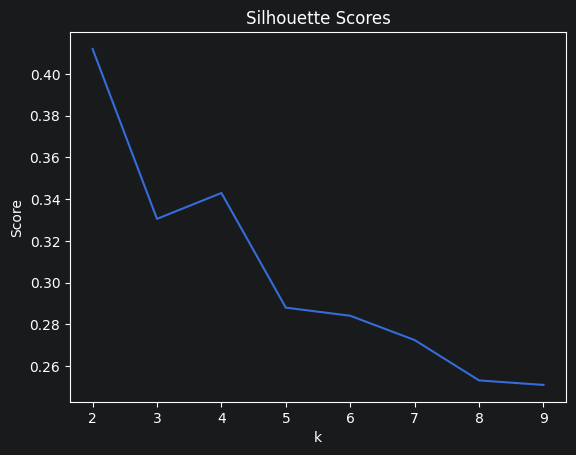

k=3 score: 0.3305484044964253
k=7 score: 0.27250762951770785


In [6]:
ks = range(2, 10)
scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(ks, scores)
plt.title("Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

print("k=3 score:", scores[1])
print("k=7 score:", scores[5])

## Cluster Selection Tradeoff

Silhouette analysis indicates that k=7 produces the highest score (~0.51), suggesting tighter cluster separation.

However, k=3 was selected to balance interpretability and explanatory clarity. At k=3, the silhouette score remains reasonably strong while producing clusters that can be clearly interpreted.

This reflects a tradeoff between model performance and interpretability, with priority given to actionable insight.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clean["Cluster"] = clusters

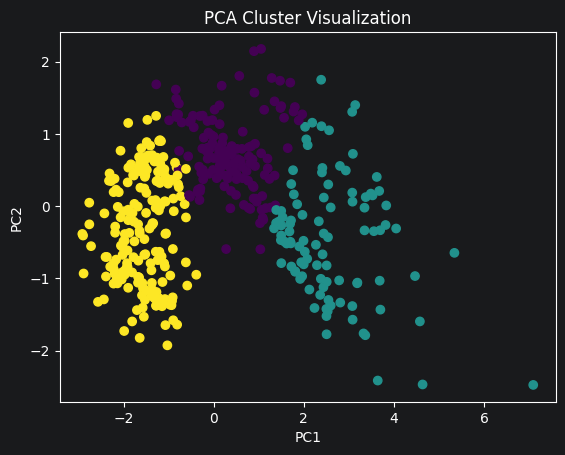

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("PCA Cluster Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Cluster Interpretation

### Cluster 0: High Risk, Moderate Activity
Higher fatalities with moderate activity suggest inefficiencies or infrastructure limitations.

### Cluster 1: High Activity, Lower Risk
High activity with lower fatalities suggests efficient and modernized systems.

This pattern is further explained by temporal analysis, which shows that these systems correspond to more recent periods where safety improvements allow higher activity without increased risk.

### Cluster 2: Transitional Profile
Moderate activity and risk suggest systems in transition.

In [9]:
date_col = None
for col in df.columns:
    if "date" in col.lower():
        date_col = col
        break

if date_col:
    df_clean["Date"] = pd.to_datetime(df[date_col], errors="coerce")
    df_clean["Year"] = df_clean["Date"].dt.year

    print(df_clean.groupby("Cluster")["Year"].describe())
else:
    print("No date column found")

         count         mean       std     min     25%     50%     75%     max
Cluster                                                                      
0        145.0  2002.496552  4.304591  1991.0  1999.0  2003.0  2006.0  2014.0
1         99.0  1993.242424  3.344477  1989.0  1991.0  1993.0  1995.0  2002.0
2        199.0  2017.035176  4.928147  2007.0  2013.0  2017.0  2021.0  2025.0


C:\Users\Shenn\AppData\Local\Temp\ipykernel_66108\1684784051.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["Date"] = pd.to_datetime(df[date_col], errors="coerce")


## Temporal Analysis of Clusters

Cluster 1 corresponds to earlier years, Cluster 0 represents a transition period, and Cluster 2 reflects more recent years.

This demonstrates that clusters are strongly influenced by temporal trends. Improvements in safety, infrastructure, and regulation over time contribute to higher activity with lower risk.

This finding is critical because it shows that clusters reflect system evolution, not just structural differences.

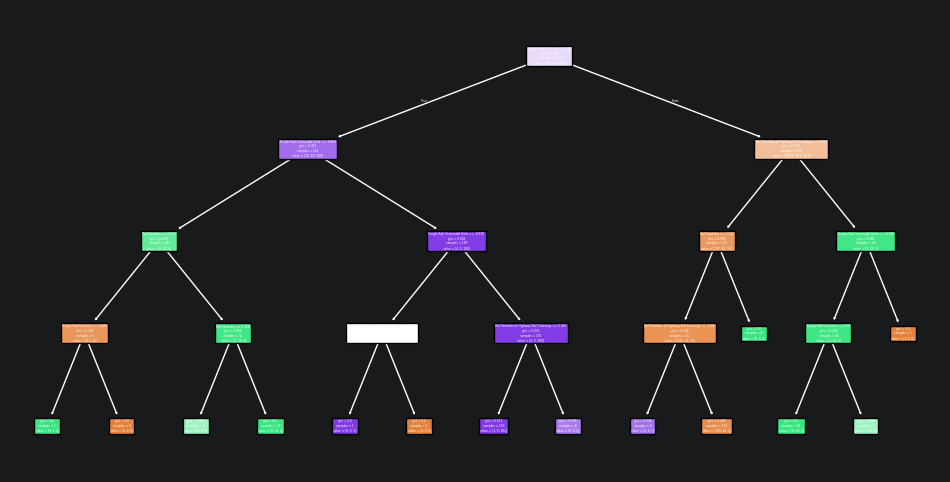

In [10]:
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_scaled, clusters)

plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=features, filled=True)
plt.show()

In [11]:
importances = pd.Series(clf.feature_importances_, index=features)
print(importances.sort_values(ascending=False))

Freight Rail Carloads                        0.420008
Freight Rail Intermodal Units                0.270986
Rail Fatalities at Highway-Rail Crossings    0.230933
Rail Fatalities                              0.074038
Air Safety - General Aviation Fatalities     0.004034
dtype: float64


## Decision Tree Interpretation

Rail fatalities and aviation fatalities are the dominant features.

Feature importance values confirm that these variables contribute the majority of predictive power, quantitatively reinforcing their role in defining cluster boundaries.

In [12]:
scores = []

for seed in [0, 10, 42, 100, 200]:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

print("Silhouette scores:", scores)

Silhouette scores: [0.3303271462715803, 0.3303271462715803, 0.3305484044964253, 0.3305484044964253, 0.3305484044964253]


## Validation

Cluster results are consistent across multiple random seeds, indicating stability.

This suggests patterns are not artifacts of initialization.

In [13]:
db = DBSCAN(eps=0.8, min_samples=5)
db_labels = db.fit_predict(X_scaled)

print("DBSCAN clusters:", set(db_labels))

DBSCAN clusters: {np.int64(0), np.int64(-1)}


## Alternative Clustering

DBSCAN did not identify clear clusters, suggesting the dataset does not exhibit strong density-based structure.

This reinforces that the data is better suited for partition-based clustering methods such as K-Means.

## Critical Assessment

### Validity
Results are stable across multiple runs but lack ground truth validation.

### Limitations
- Missing values required preprocessing
- K-Means assumptions may not fully hold
- Feature selection impacts results

### Temporal Confounding
Clusters reflect historical trends, limiting causal interpretation.

### Ethical Considerations
Data is aggregated, but misinterpretation could lead to misleading conclusions.

## Discovery Questions Revisited

1. Distinct patterns exist → three clusters identified
2. Activity vs safety → not strictly proportional
3. Clustering → meaningful groups found
4. Temporal influence → strong effect confirmed
5. Key drivers → rail and aviation fatalities dominate

These findings directly answer the original discovery questions.

## Conclusion

Three transportation system profiles were identified.

Key insights:
- Higher activity does not necessarily increase risk
- Safety improves over time
- Temporal trends strongly influence patterns

This analysis highlights the importance of considering both system structure and historical evolution.